In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime



In [2]:
df = pd.read_csv('../../datasets/clean-data-pm10.csv')
df['datetime'] = pd.to_datetime(df['datetime'], format = '%Y-%m-%d %H:%M:%S')
print(df.info())
df.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  292 non-null    datetime64[ns]
 1   PM10      292 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.7 KB
None


,datetime,PM10
0,2020-01-01,42.0
1,2020-01-02,39.0


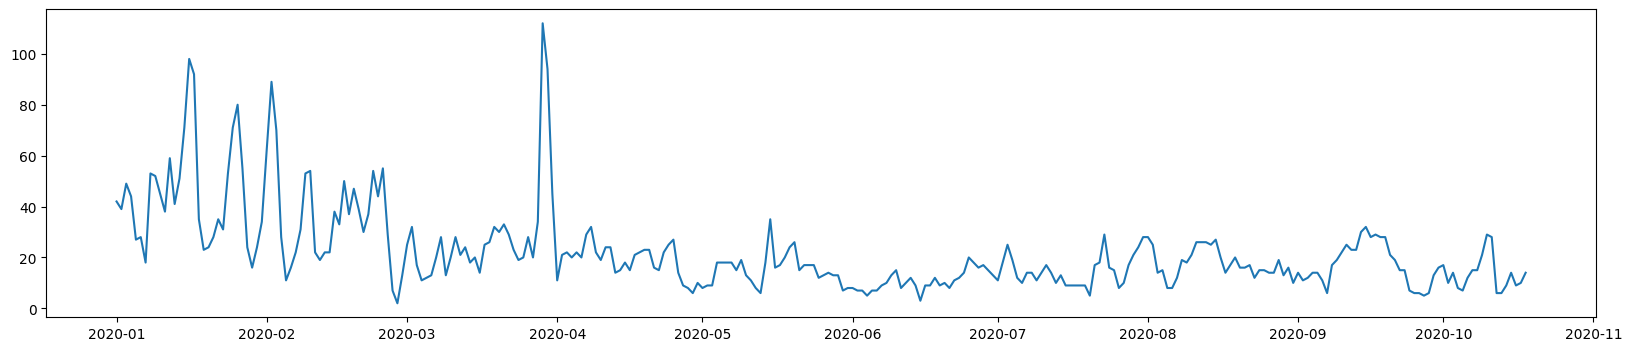

In [3]:
plt.figure(figsize = (20, 4))
plt.plot(df['datetime'], df['PM10'])
plt.show()

In [4]:
df['PM10-1'] = df['PM10'].shift(1)
df['PM10-2'] = df['PM10'].shift(2)
df['PM10-3'] = df['PM10'].shift(3)
df = df.dropna()
df.head(5)

,datetime,PM10,PM10-1,PM10-2,PM10-3
3,2020-01-04,44.0,49.0,39.0,42.0
4,2020-01-05,27.0,44.0,49.0,39.0
5,2020-01-06,28.0,27.0,44.0,49.0
6,2020-01-07,18.0,28.0,27.0,44.0
7,2020-01-08,53.0,18.0,28.0,27.0


In [5]:
tt_split = datetime.strptime('2020-05-02 00:00:00','%Y-%m-%d %H:%M:%S')
train = df[df['datetime'] <= tt_split]
test = df[df['datetime'] > tt_split]
X_train = train[['PM10-1', 'PM10-2', 'PM10-3']]
y_train = train['PM10']
X_test = test[['PM10-1', 'PM10-2', 'PM10-3']]
y_test = test['PM10']

In [6]:
from keras.models import Sequential
from keras.layers import Dense, Input

input_shape = (X_train.shape[1],)
model = Sequential([
Input(shape=input_shape),
Dense(10, activation="relu"),
Dense(10, activation="relu"),
Dense(10, activation="relu"),
Dense(1, activation="linear")
])


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271 (1.06 KB)

 Trainable params: 271 (1.06 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from keras.callbacks import EarlyStopping
model.compile(loss='mse', optimizer='adam')
es = EarlyStopping(monitor='val_loss', patience=10)
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[es])

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 2102.7524 - val_loss: 405.7515
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2039.8492 - val_loss: 394.7044
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1929.8789 - val_loss: 384.2611
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1869.7963 - val_loss: 374.6058
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1918.8787 - val_loss: 365.5933
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 2062.4321 - val_loss: 357.4070
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 1840.9720 - val_loss: 349.8752
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1888.9354 - val_loss: 343.0210
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1438.5604 - val_loss: 336.7334
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 1985.2570 - val_loss: 330.7161
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1669.3251 - val_loss: 324.8613
Epoch 12/100
3/3 ━

In [8]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


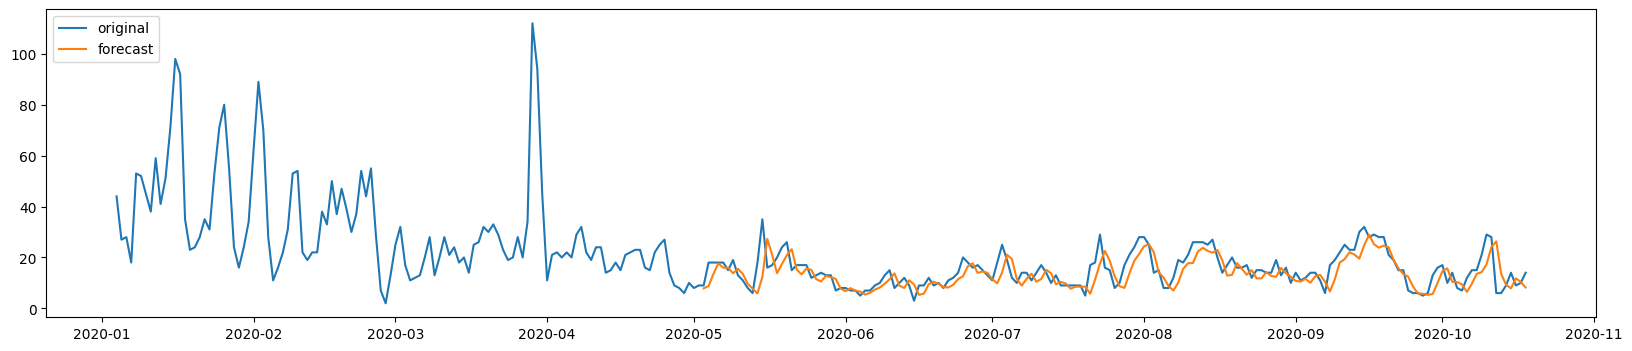

In [9]:
plt.figure(figsize = (20, 4))
plt.plot(df['datetime'],df['PM10'],label='original')
plt.plot(test['datetime'],y_test_pred,label='forecast')
plt.legend(loc="upper left")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━

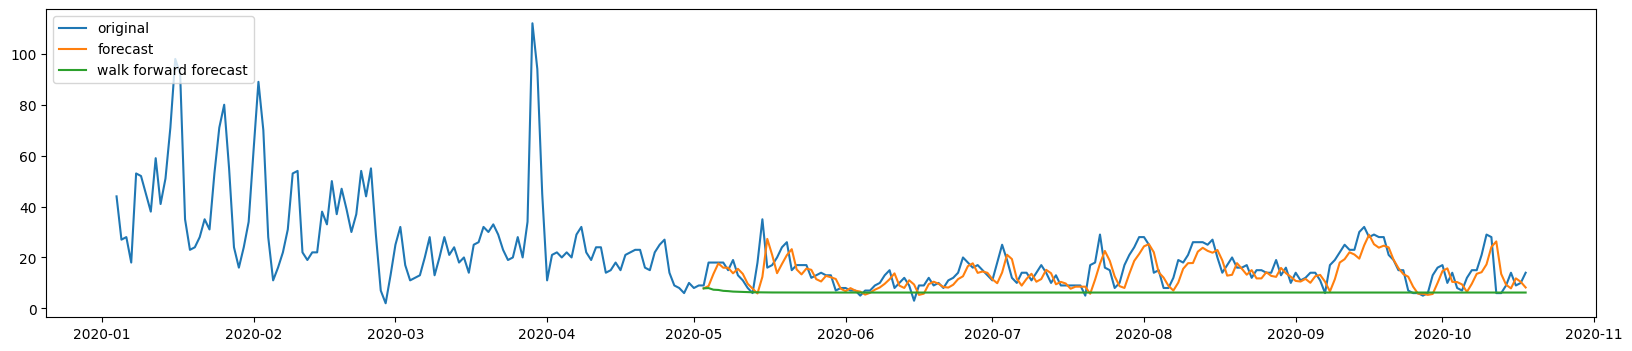

In [10]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

# walk forward predictions, forecast multiple step in advance

last = train.iloc[-1,:]

history = [last['PM10'],last['PM10-1'],last['PM10-2']]

h = np.array(history).reshape(1,3)
predictions =[model.predict(h)[0][0]]

for t in range(len(test)-1):
    history[2] = history[1]
    history[1] = history[0]
    history[0] = predictions[-1]
    h = np.array(history).reshape(1,3)
    predictions.append(model.predict(h)[0][0])
    
plt.figure(figsize = (20, 4))
plt.plot(df['datetime'],df['PM10'],label='original')
plt.plot(test['datetime'],y_test_pred,label='forecast')
plt.plot(test['datetime'],predictions,label='walk forward forecast')
plt.legend(loc="upper left")
plt.show()